In [1]:
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from langgraph.graph import StateGraph, START, MessagesState, END
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage
from langchain_core.messages import HumanMessage
load_dotenv()

True

In [2]:
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [3]:
class ChatState(MessagesState):
    summary: str

In [4]:

def summarize_conversation(state: ChatState):
    existing_summary = state["summary"]
    if len(existing_summary)>0:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above. Return only the updated summary, do not include the conversation in your response."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = llm.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

def chat_node(state: ChatState):
    messages = []
    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = llm.invoke(messages)
    return {"messages": [response]}

def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [5]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

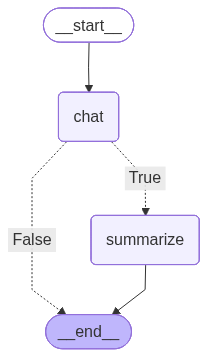

In [6]:
checkpointer = InMemorySaver()
workflow = builder.compile(checkpointer=checkpointer)
workflow

In [7]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = workflow.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [8]:
def show_state():
    snap = workflow.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [9]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='5423a887-e2d2-4034-bb52-2f2c089d5b10')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : ## Quantum Physics – A Quick‑Start Guide  

Below is a compact yet fairly comple


In [10]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='5423a887-e2d2-4034-bb52-2f2c089d5b10'), AIMessage(content='## Quantum Physics – A Quick‑Start Guide  \n\nBelow is a compact yet fairly complete overview of quantum physics, organized so you can dip in at any level—whether you’re a curious layperson, a student looking for a study roadmap, or a researcher needing a handy refresher.\n\n---\n\n### 1. What Is Quantum Physics?\n\n**Quantum physics (or quantum mechanics)** is the branch of physics that describes how nature behaves on the smallest scales—atoms, electrons, photons, and other elementary particles. Its hallmark is that many quantities we take for granted as continuous and deterministic in everyday life become **discrete (quantized)** and **probabilistic** at the quantum level.\n\n| Classical intuition | Quantum reality |\n|---------------------|-----------------|\n| Particles have definite position & momentum simultaneously | Heisenberg’s Unc

In [11]:
run_turn('What are some of Einstien"s famous work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='5423a887-e2d2-4034-bb52-2f2c089d5b10'), AIMessage(content='## Quantum Physics – A Quick‑Start Guide  \n\nBelow is a compact yet fairly complete overview of quantum physics, organized so you can dip in at any level—whether you’re a curious layperson, a student looking for a study roadmap, or a researcher needing a handy refresher.\n\n---\n\n### 1. What Is Quantum Physics?\n\n**Quantum physics (or quantum mechanics)** is the branch of physics that describes how nature behaves on the smallest scales—atoms, electrons, photons, and other elementary particles. Its hallmark is that many quantities we take for granted as continuous and deterministic in everyday life become **discrete (quantized)** and **probabilistic** at the quantum level.\n\n| Classical intuition | Quantum reality |\n|---------------------|-----------------|\n| Particles have definite position & momentum simultaneously | Heisenberg’s Unc